In [35]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

from transformers import Wav2Vec2Processor, Wav2Vec2ForSequenceClassification
import torch
import torchaudio
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from tqdm import tqdm
from pathlib import Path
from tabulate import tabulate

In [36]:
# Path to your unzipped model directory
model_path = Path(r"C:\Users\nagap\OneDrive\Documentos\Maestria\2025S\Phonetics TeamLab\DrunkenLinguists\v5_ext_split\run_20250622_183210\best_wav2vec2_model")

# Load processor (tokenizer + feature extractor for audio)
processor = Wav2Vec2Processor.from_pretrained(model_path)

# Load model from .safetensors
model = Wav2Vec2ForSequenceClassification.from_pretrained(model_path, trust_remote_code=True)
model.eval()

Wav2Vec2ForSequenceClassification(
  (wav2vec2): Wav2Vec2Model(
    (feature_extractor): Wav2Vec2FeatureEncoder(
      (conv_layers): ModuleList(
        (0): Wav2Vec2LayerNormConvLayer(
          (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,))
          (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (activation): GELUActivation()
        )
        (1-4): 4 x Wav2Vec2LayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,))
          (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (activation): GELUActivation()
        )
        (5-6): 2 x Wav2Vec2LayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,))
          (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (activation): GELUActivation()
        )
      )
    )
    (feature_projection): Wav2Vec2FeatureProjection(
      (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=

In [37]:
"""
#folder = Path(r"C:\Users\nagap\OneDrive\Documentos\Maestria\2025S\Phonetics TeamLab\ALC")
audioList_file = "wav_labelsTestUpdated.csv"
test_file = os.path.join(folder,audioList_file)

df = pd.read_csv(test_file,header=None,delimiter=',',dtype={6: str})
# 0: session folder
# 1: recording name
# 2: drunk flag
# 3: bak level
# 4: prompt set
# 5: task id (according to prompt set)
# 6: merge task id

df[2]=df[2].apply(lambda x: 1 if x=='A' else 0)
prediction_results = []
for sample in tqdm(df.itertuples(index=False), total=len(df), desc="Processing audio files"):
    # Load audio
    recording_folder = sample[0]
    file_name = sample[1]
    full_filepath = Path(recording_folder) / file_name

    try:
        speech_array, sampling_rate = torchaudio.load(full_filepath)
    except Exception as e:
        print(f"Error loading {full_filepath}: {e}")
        prediction_results.append(None)
        continue

    # Resample if needed
    if sampling_rate != 16000:
        resampler = torchaudio.transforms.Resample(orig_freq=sampling_rate, new_freq=16000)
        speech_array = resampler(speech_array)


    # Remove extra channel dimension, Convert to mono
    if speech_array.shape[0] > 1:
        speech_array = torch.mean(speech_array, dim=0)
    else:
        speech_array = speech_array.squeeze()


    # Preprocess
    inputs = processor(speech_array, sampling_rate=16000, return_tensors="pt", padding=True)

    # Forward pass
    with torch.no_grad():
        logits = model(**inputs).logits

    # Get prediction
    predicted_class_id = torch.argmax(logits, dim=-1).item()
    #print(f"Predicted class ID: {predicted_class_id}")
    prediction_results.append(predicted_class_id)

df[7] = prediction_results

#Storing prediction results
output_csv = os.path.join(folder, 'testPredictionResults2.csv')
df.to_csv(output_csv, index=False)"""

SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 20-21: truncated \UXXXXXXXX escape (67216413.py, line 1)

In [38]:
#Loading test prediction file
folder = Path(r"C:\Users\nagap\OneDrive\Documentos\Maestria\2025S\Phonetics TeamLab\ALC")
prediction_csv = os.path.join(folder, 'testPredictionResults.csv')

df = pd.read_csv(prediction_csv,delimiter=',',header=0,dtype={6: str})

df.columns = [
    "Folder",       # 0
    "RecordName",   # 1
    "DrunkFlag",    # 2
    "BacLevel",     # 3
    "PromptSet",    # 4
    "TaskID",       # 5
    "MergeID",      # 6
    "Prediction"    #7
]

df["MergeID"] = df["MergeID"].astype(str)
df.head()

,Folder,RecordName,DrunkFlag,BacLevel,PromptSet,TaskID,MergeID,Prediction
0,c:\Users\nagap\OneDrive\Documentos\Maestria\20...,5653066001_h_01.wav,1,0.00109,DRUNK,1,001,1
1,c:\Users\nagap\OneDrive\Documentos\Maestria\20...,5653066002_h_00.wav,1,0.00109,DRUNK,2,034,0
2,c:\Users\nagap\OneDrive\Documentos\Maestria\20...,5653066003_h_00.wav,1,0.00109,DRUNK,3,032,1
3,c:\Users\nagap\OneDrive\Documentos\Maestria\20...,5653066004_h_00.wav,1,0.00109,DRUNK,4,061,1
4,c:\Users\nagap\OneDrive\Documentos\Maestria\20...,5653066005_h_00.wav,1,0.00109,DRUNK,5,030,1


In [39]:
#Reading task metadata to get types and subtypes
task_folder = Path(r"C:\Users\nagap\OneDrive\Documentos\Maestria\2025S\Phonetics TeamLab\ALC")
task_file = os.path.join(task_folder, 'TaskACL.xlsx')
task_metadata = pd.read_excel(task_file, sheet_name='Full list',dtype={'MergeID': str})
#task_metadata = pd.read_excel(task_file, sheet_name='New grouping',dtype={'MergeID': str})

#0: MergeID
#1: Type
#2: Subtype

#Adding this info to our prediction results
merged_dfTrain = df.merge(task_metadata, on='MergeID', how='left')
merged_dfTrain.head()

,Folder,RecordName,DrunkFlag,BacLevel,PromptSet,TaskID,MergeID,Prediction,Type,Subtype,Description
0,c:\Users\nagap\OneDrive\Documentos\Maestria\20...,5653066001_h_01.wav,1,0.00109,DRUNK,1,001,1,Reading,Read a number,Bitte lesen Sie die Telefonnummer: +491763582901
1,c:\Users\nagap\OneDrive\Documentos\Maestria\20...,5653066002_h_00.wav,1,0.00109,DRUNK,2,034,0,Open question,Tell a story,Bitte sprechen Sie mit dem Versuchsleiter: Erz...
2,c:\Users\nagap\OneDrive\Documentos\Maestria\20...,5653066003_h_00.wav,1,0.00109,DRUNK,3,032,1,Reading,Rapid word list,Bitte so schnell wie möglich lesen: Messwechse...
3,c:\Users\nagap\OneDrive\Documentos\Maestria\20...,5653066004_h_00.wav,1,0.00109,DRUNK,4,061,1,Reading,Read an address,Bitte lesen die Adresse: Ernst-Fahlbusch-Straß...
4,c:\Users\nagap\OneDrive\Documentos\Maestria\20...,5653066005_h_00.wav,1,0.00109,DRUNK,5,030,1,Open question,Describe an image,Erzählen Sie eine Geschichte zum Bild - tat_13MF


### General inspection of test data set

COUNT OF TYPE SAMPLES PER DRUNK FLAG
╒═══════════════╤═════════╤═════════╤═════════╤═══════════╤═══════════╕
│ Type          │   Drunk │   Sober │   Total │   % Sober │   % Drunk │
╞═══════════════╪═════════╪═════════╪═════════╪═══════════╪═══════════╡
│ Open question │     460 │     540 │    1000 │    54.00% │    46.00% │
├───────────────┼─────────┼─────────┼─────────┼───────────┼───────────┤
│ Reading       │     920 │    1080 │    2000 │    54.00% │    46.00% │
╘═══════════════╧═════════╧═════════╧═════════╧═══════════╧═══════════╛


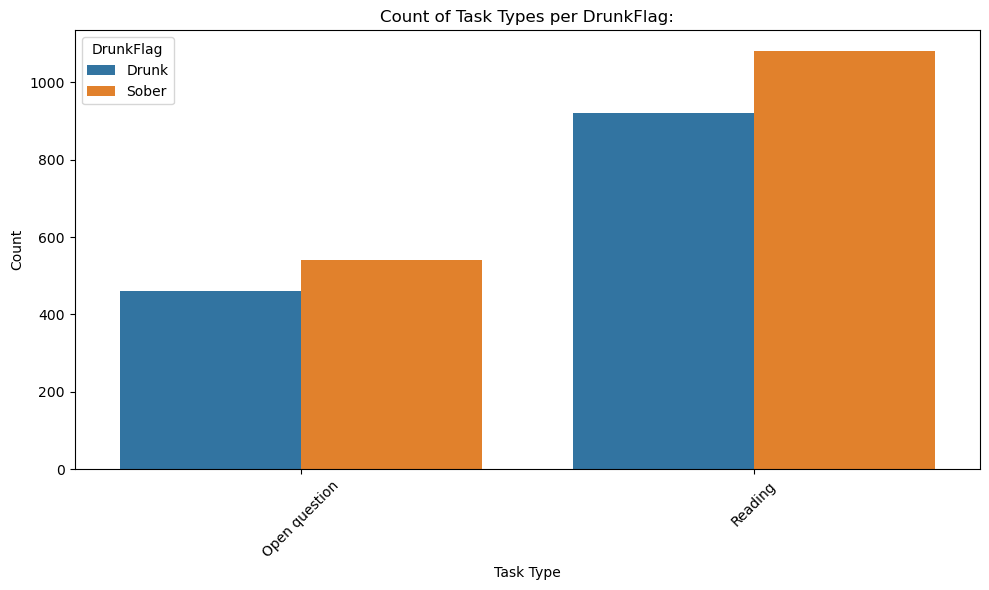

In [40]:
print("COUNT OF TYPE SAMPLES PER DRUNK FLAG")
type_counts = merged_dfTrain.groupby(['DrunkFlag','Type']).size().reset_index(name='Count')
type_counts['DrunkFlag'] = type_counts['DrunkFlag'].map({0: 'Sober', 1: 'Drunk'})
pivot_type_counts = type_counts.pivot_table(index='Type', columns='DrunkFlag', values='Count', 
                                            fill_value=0).reset_index()
#pivot_type_counts = pivot_type_counts.rename(columns={0: 'Sober', 1: 'Drunk'})

# Add a total column and sort by it
pivot_type_counts['Total'] = pivot_type_counts['Sober'] + pivot_type_counts['Drunk']
pivot_type_counts['% Sober'] = pivot_type_counts['Sober']/pivot_type_counts['Total']
pivot_type_counts['% Drunk'] = 1-pivot_type_counts['Sober']/pivot_type_counts['Total']

print(
    tabulate(
        pivot_type_counts,
        headers='keys',
        showindex=False,
        tablefmt='fancy_grid',
        floatfmt=(".0f", ".0f", ".0f", ".0f", ".2%", ".2%")
    )
)

type_counts.sort_values(by='Type', ascending=True, inplace=True)
label_order=['Drunk','Sober']
plt.figure(figsize=(10,6))
sns.barplot(data=type_counts, x='Type', y='Count', hue='DrunkFlag',hue_order=label_order)

plt.title('Count of Task Types per {}:'.format('DrunkFlag'))
plt.xlabel('Task Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='DrunkFlag')
plt.tight_layout()
plt.show()


COUNT OF SUBTYPE OF TASK ACCORDING TO TASK SET
╒═══════════════╤═══════════════════════╤═════════╤═════════╤═════════╤═══════════╤═══════════╕
│ Type          │ Subtype               │   Drunk │   Sober │   Total │   % Sober │   % Drunk │
╞═══════════════╪═══════════════════════╪═════════╪═════════╪═════════╪═══════════╪═══════════╡
│ Open question │ Describe an image     │     138 │     162 │     300 │    54.00% │    46.00% │
├───────────────┼───────────────────────┼─────────┼─────────┼─────────┼───────────┼───────────┤
│ Open question │ Issue a command       │     230 │     270 │     500 │    54.00% │    46.00% │
├───────────────┼───────────────────────┼─────────┼─────────┼─────────┼───────────┼───────────┤
│ Open question │ Tell a story          │      92 │     108 │     200 │    54.00% │    46.00% │
├───────────────┼───────────────────────┼─────────┼─────────┼─────────┼───────────┼───────────┤
│ Reading       │ Rapid word list       │      92 │     108 │     200 │    54.00% │    4

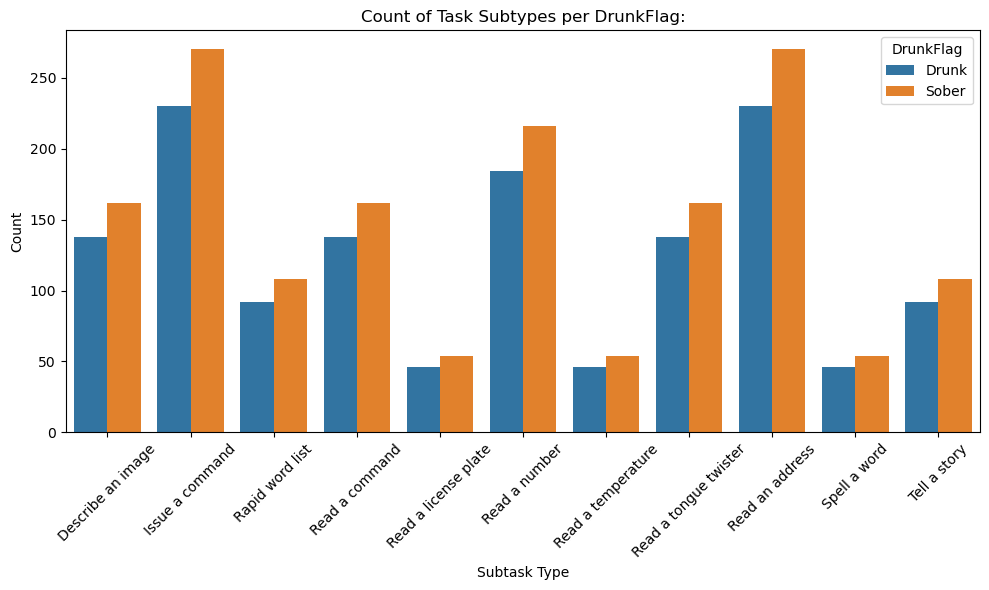

In [41]:
print("\nCOUNT OF SUBTYPE OF TASK ACCORDING TO TASK SET")
subtype_counts = merged_dfTrain.groupby(['DrunkFlag', 'Type', 'Subtype']).size().reset_index(name='Count')
subtype_counts['DrunkFlag'] = subtype_counts['DrunkFlag'].map({0: 'Sober', 1: 'Drunk'})
pivot_subtype_counts = subtype_counts.pivot_table(index=['Type', 'Subtype'], 
                                            columns='DrunkFlag', 
                                            values='Count', 
                                            fill_value=0).reset_index()

#pivot_subtype_counts = pivot_subtype_counts.rename(columns={0: 'Sober', 1: 'Drunk'})
# Add a total column and sort by it
pivot_subtype_counts['Total'] = pivot_subtype_counts['Sober'] + pivot_subtype_counts['Drunk']
pivot_subtype_counts['% Sober'] = pivot_subtype_counts['Sober']/pivot_subtype_counts['Total']
pivot_subtype_counts['% Drunk'] = 1-pivot_subtype_counts['Sober']/pivot_subtype_counts['Total']
print(
    tabulate(
        pivot_subtype_counts,
        headers='keys',
        showindex=False,
        tablefmt='fancy_grid',
        floatfmt=(".0f", ".0f", ".0f", ".0f", ".0f", ".2%", ".2%")
    )
)

subtype_counts.sort_values(by='Subtype', ascending=True, inplace=True)
label_order=['Drunk','Sober']
plt.figure(figsize=(10,6))
sns.barplot(data=subtype_counts, x='Subtype', y='Count', hue='DrunkFlag',hue_order=label_order)

plt.title('Count of Task Subtypes per {}:'.format('DrunkFlag'))
plt.xlabel('Subtask Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='DrunkFlag')
plt.tight_layout()
plt.show()

## Analyzing predictions

In [42]:
#Overall
merged_dfTrain["RightFlag"] = merged_dfTrain["DrunkFlag"]==merged_dfTrain["Prediction"]
predAll_counts = merged_dfTrain.groupby(['Prediction', 'RightFlag']).size().reset_index(name='Count')
predAll_counts['Prediction'] = predAll_counts['Prediction'].map({0: 'Sober', 1: 'Drunk'})
predAll_counts['RightFlag'] = predAll_counts['RightFlag'].map({False: 'Wrong', True: 'Right'})
pivot_predAll_counts = predAll_counts.pivot_table(index=['Prediction'], 
                                            columns='RightFlag', 
                                            values='Count', 
                                            fill_value=0).reset_index()
pivot_predAll_counts['Total'] = pivot_predAll_counts['Wrong'] + pivot_predAll_counts['Right']
pivot_predAll_counts['% Right'] = pivot_predAll_counts['Right']/pivot_predAll_counts['Total']
pivot_predAll_counts['% Wrong'] = 1-pivot_predAll_counts['Right']/pivot_predAll_counts['Total']

print("OVERALL PREDICTION RESULTS")
print(
    tabulate(
        pivot_predAll_counts,
        headers='keys',
        showindex=False,
        tablefmt='fancy_grid',
        floatfmt=(".0f", ".0f", ".0f", ".0f", ".2%", ".2%")
    )
)

OVERALL PREDICTION RESULTS
╒══════════════╤═════════╤═════════╤═════════╤═══════════╤═══════════╕
│ Prediction   │   Right │   Wrong │   Total │   % Right │   % Wrong │
╞══════════════╪═════════╪═════════╪═════════╪═══════════╪═══════════╡
│ Drunk        │    1102 │     466 │    1568 │    70.28% │    29.72% │
├──────────────┼─────────┼─────────┼─────────┼───────────┼───────────┤
│ Sober        │    1154 │     278 │    1432 │    80.59% │    19.41% │
╘══════════════╧═════════╧═════════╧═════════╧═══════════╧═══════════╛


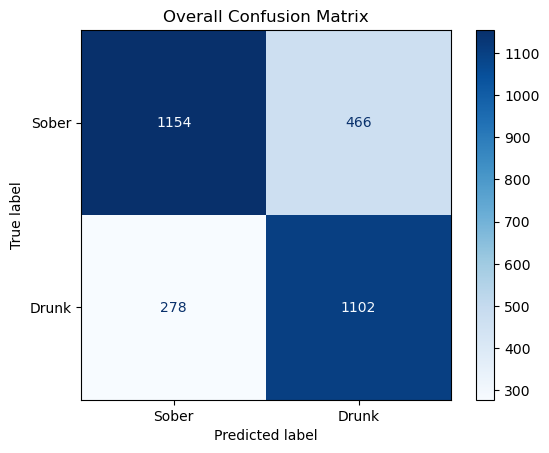

In [43]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(merged_dfTrain['DrunkFlag'], merged_dfTrain['Prediction'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Sober','Drunk'])
disp.plot(cmap='Blues')
plt.title("Overall Confusion Matrix")
plt.show()


In [44]:
#Task-category wise
pred_counts = merged_dfTrain.groupby(['RightFlag','Type']).size().reset_index(name='Count')
pred_counts['RightFlag'] = pred_counts['RightFlag'].map({False: 'Wrong', True: 'Right'})
pivot_predAllT_counts = pred_counts.pivot_table(index=['Type'], 
                                            columns='RightFlag', 
                                            values='Count', 
                                            fill_value=0).reset_index()

pivot_predAllT_counts['Total'] = pivot_predAllT_counts['Wrong'] + pivot_predAllT_counts['Right']
pivot_predAllT_counts['% Right'] = pivot_predAllT_counts['Right']/pivot_predAllT_counts['Total']
pivot_predAllT_counts['% Wrong'] = 1-pivot_predAllT_counts['Right']/pivot_predAllT_counts['Total']

# Sort descending by % Right
pivot_predAllT_counts = pivot_predAllT_counts.sort_values(by='% Right', ascending=False).reset_index(drop=True)


print('TASK-TYPE PREDICTION RESULTS')
print(
    tabulate(
        pivot_predAllT_counts,
        headers='keys',
        showindex=False,
        tablefmt='fancy_grid',
        floatfmt=(".0f", ".0f", ".0f", ".0f", ".2%", ".2%")
    )
)


TASK-TYPE PREDICTION RESULTS
╒═══════════════╤═════════╤═════════╤═════════╤═══════════╤═══════════╕
│ Type          │   Right │   Wrong │   Total │   % Right │   % Wrong │
╞═══════════════╪═════════╪═════════╪═════════╪═══════════╪═══════════╡
│ Open question │     765 │     235 │    1000 │    76.50% │    23.50% │
├───────────────┼─────────┼─────────┼─────────┼───────────┼───────────┤
│ Reading       │    1491 │     509 │    2000 │    74.55% │    25.45% │
╘═══════════════╧═════════╧═════════╧═════════╧═══════════╧═══════════╛


In [45]:
#Task-category wise
pred_counts = merged_dfTrain.groupby(['Prediction', 'RightFlag','Type']).size().reset_index(name='Count')
pred_counts['Prediction'] = pred_counts['Prediction'].map({0: 'Sober', 1: 'Drunk'})
pred_counts['RightFlag'] = pred_counts['RightFlag'].map({False: 'Wrong', True: 'Right'})
pivot_predAllT_counts = pred_counts.pivot_table(index=['Prediction', 'Type'], 
                                            columns='RightFlag', 
                                            values='Count', 
                                            fill_value=0).reset_index()

pivot_predAllT_counts['Total'] = pivot_predAllT_counts['Wrong'] + pivot_predAllT_counts['Right']
pivot_predAllT_counts['% Right'] = pivot_predAllT_counts['Right']/pivot_predAllT_counts['Total']
pivot_predAllT_counts['% Wrong'] = 1-pivot_predAllT_counts['Right']/pivot_predAllT_counts['Total']

# Sort descending by % Right
pivot_predAllT_counts = pivot_predAllT_counts.sort_values(by='% Right', ascending=False).reset_index(drop=True)


print('TASK-TYPE PREDICTION RESULTS')
print(
    tabulate(
        pivot_predAllT_counts,
        headers='keys',
        showindex=False,
        tablefmt='fancy_grid',
        floatfmt=(".0f", ".0f", ".0f", ".0f", ".0f", ".2%", ".2%")
    )
)



TASK-TYPE PREDICTION RESULTS
╒══════════════╤═══════════════╤═════════╤═════════╤═════════╤═══════════╤═══════════╕
│ Prediction   │ Type          │   Right │   Wrong │   Total │   % Right │   % Wrong │
╞══════════════╪═══════════════╪═════════╪═════════╪═════════╪═══════════╪═══════════╡
│ Sober        │ Open question │     401 │      96 │     497 │    80.68% │    19.32% │
├──────────────┼───────────────┼─────────┼─────────┼─────────┼───────────┼───────────┤
│ Sober        │ Reading       │     753 │     182 │     935 │    80.53% │    19.47% │
├──────────────┼───────────────┼─────────┼─────────┼─────────┼───────────┼───────────┤
│ Drunk        │ Open question │     364 │     139 │     503 │    72.37% │    27.63% │
├──────────────┼───────────────┼─────────┼─────────┼─────────┼───────────┼───────────┤
│ Drunk        │ Reading       │     738 │     327 │    1065 │    69.30% │    30.70% │
╘══════════════╧═══════════════╧═════════╧═════════╧═════════╧═══════════╧═══════════╛


In [46]:
#Task-subtype wise
predST_counts = merged_dfTrain.groupby(['RightFlag','Subtype']).size().reset_index(name='Count')
predST_counts['RightFlag'] = predST_counts['RightFlag'].map({False: 'Wrong', True: 'Right'})
pivot_predAllST_counts = predST_counts.pivot_table(index=['Subtype'], 
                                            columns='RightFlag', 
                                            values='Count', 
                                            fill_value=0).reset_index()

pivot_predAllST_counts['Total'] = pivot_predAllST_counts['Wrong'] + pivot_predAllST_counts['Right']
pivot_predAllST_counts['% Right'] = pivot_predAllST_counts['Right']/pivot_predAllST_counts['Total']
pivot_predAllST_counts['% Wrong'] = 1-pivot_predAllST_counts['Right']/pivot_predAllST_counts['Total']

# Sort descending by % Right
pivot_predAllST_counts = pivot_predAllST_counts.sort_values(by='% Right', ascending=False).reset_index(drop=True)


print('TASK-SUBTYPE PREDICTION RESULTS')
print(
    tabulate(
        pivot_predAllST_counts,
        headers='keys',
        showindex=False,
        tablefmt='fancy_grid',
        floatfmt=(".0f", ".0f", ".0f", ".0f", ".2%", ".2%")
    )
)

TASK-SUBTYPE PREDICTION RESULTS
╒═══════════════════════╤═════════╤═════════╤═════════╤═══════════╤═══════════╕
│ Subtype               │   Right │   Wrong │   Total │   % Right │   % Wrong │
╞═══════════════════════╪═════════╪═════════╪═════════╪═══════════╪═══════════╡
│ Describe an image     │     240 │      60 │     300 │    80.00% │    20.00% │
├───────────────────────┼─────────┼─────────┼─────────┼───────────┼───────────┤
│ Read an address       │     390 │     110 │     500 │    78.00% │    22.00% │
├───────────────────────┼─────────┼─────────┼─────────┼───────────┼───────────┤
│ Read a number         │     311 │      89 │     400 │    77.75% │    22.25% │
├───────────────────────┼─────────┼─────────┼─────────┼───────────┼───────────┤
│ Spell a word          │      77 │      23 │     100 │    77.00% │    23.00% │
├───────────────────────┼─────────┼─────────┼─────────┼───────────┼───────────┤
│ Read a license plate  │      76 │      24 │     100 │    76.00% │    24.00% │
├───────

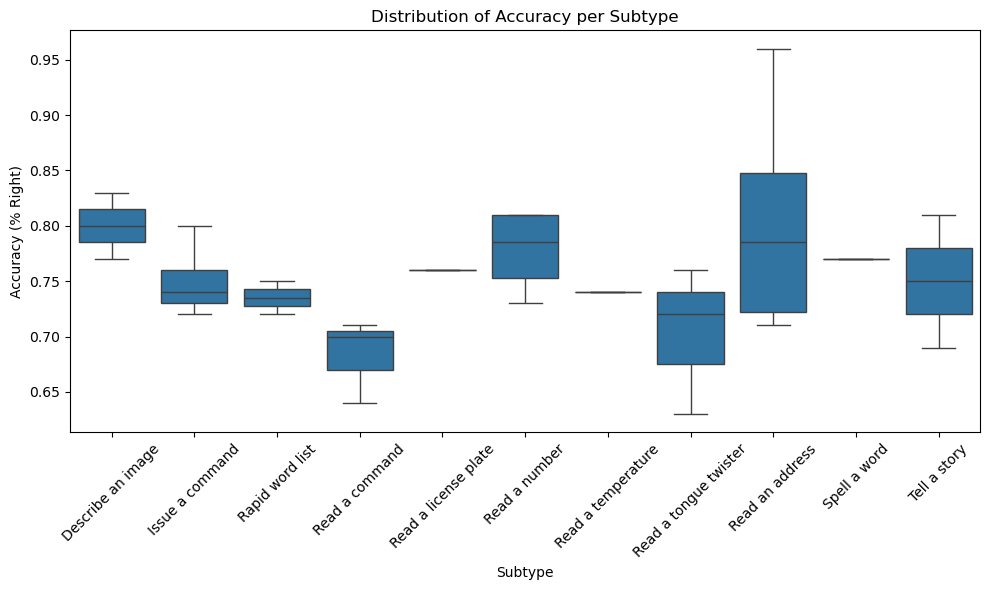

In [47]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=pivot_predTask_counts,
    x='Subtype',
    y='% Right'
)
plt.xticks(rotation=45)
plt.ylabel("Accuracy (% Right)")
plt.title("Distribution of Accuracy per Subtype")
plt.tight_layout()
plt.show()


In [48]:
#Task-subtype wise
predST_counts = merged_dfTrain.groupby(['Subtype','Prediction', 'RightFlag']).size().reset_index(name='Count')
predST_counts['Prediction'] = predST_counts['Prediction'].map({0: 'Sober', 1: 'Drunk'})
predST_counts['RightFlag'] = predST_counts['RightFlag'].map({False: 'Wrong', True: 'Right'})
pivot_predAllST_counts = predST_counts.pivot_table(index=['Prediction', 'Subtype'], 
                                            columns='RightFlag', 
                                            values='Count', 
                                            fill_value=0).reset_index()

pivot_predAllST_counts['Total'] = pivot_predAllST_counts['Wrong'] + pivot_predAllST_counts['Right']
pivot_predAllST_counts['% Right'] = pivot_predAllST_counts['Right']/pivot_predAllST_counts['Total']
pivot_predAllST_counts['% Wrong'] = 1-pivot_predAllST_counts['Right']/pivot_predAllST_counts['Total']

# Sort descending by % Right
pivot_predAllST_counts = pivot_predAllST_counts.sort_values(by='% Right', ascending=False).reset_index(drop=True)


print('TASK-SUBTYPE PREDICTION RESULTS')
print(
    tabulate(
        pivot_predAllST_counts,
        headers='keys',
        showindex=False,
        tablefmt='fancy_grid',
        floatfmt=(".0f", ".0f", ".0f", ".0f", ".0f", ".2%", ".2%")
    )
)

TASK-SUBTYPE PREDICTION RESULTS
╒══════════════╤═══════════════════════╤═════════╤═════════╤═════════╤═══════════╤═══════════╕
│ Prediction   │ Subtype               │   Right │   Wrong │   Total │   % Right │   % Wrong │
╞══════════════╪═══════════════════════╪═════════╪═════════╪═════════╪═══════════╪═══════════╡
│ Sober        │ Read a tongue twister │      84 │      11 │      95 │    88.42% │    11.58% │
├──────────────┼───────────────────────┼─────────┼─────────┼─────────┼───────────┼───────────┤
│ Sober        │ Read an address       │     187 │      27 │     214 │    87.38% │    12.62% │
├──────────────┼───────────────────────┼─────────┼─────────┼─────────┼───────────┼───────────┤
│ Sober        │ Spell a word          │      37 │       6 │      43 │    86.05% │    13.95% │
├──────────────┼───────────────────────┼─────────┼─────────┼─────────┼───────────┼───────────┤
│ Sober        │ Rapid word list       │      67 │      12 │      79 │    84.81% │    15.19% │
├──────────────┼──

In [49]:
#Task-wise results
predTask_counts = merged_dfTrain.groupby(['MergeID','RightFlag']).size().reset_index(name='Count')
predTask_counts['RightFlag'] = predTask_counts['RightFlag'].map({False: 'Wrong', True: 'Right'})
pivot_predTask_counts = predTask_counts.pivot_table(index=['MergeID'], 
                                            columns='RightFlag', 
                                            values='Count', 
                                            fill_value=0).reset_index()

pivot_predTask_counts['Total'] = pivot_predTask_counts['Wrong'] + pivot_predTask_counts['Right']
pivot_predTask_counts['% Right'] = pivot_predTask_counts['Right']/pivot_predTask_counts['Total']
pivot_predTask_counts['% Wrong'] = 1-pivot_predTask_counts['Right']/pivot_predTask_counts['Total']

# Sort descending by % Right
pivot_predTask_counts = pivot_predTask_counts.sort_values(by='% Right', ascending=False).reset_index(drop=True)


print('TASK PREDICTION RESULTS')
print(
    tabulate(
        pivot_predTask_counts,
        headers='keys',
        showindex=False,
        tablefmt='fancy_grid',
        floatfmt=(".0f", ".0f", ".0f", ".0f", ".2%", ".2%")
    )
)

TASK PREDICTION RESULTS
╒═══════════╤═════════╤═════════╤═════════╤═══════════╤═══════════╕
│   MergeID │   Right │   Wrong │   Total │   % Right │   % Wrong │
╞═══════════╪═════════╪═════════╪═════════╪═══════════╪═══════════╡
│       004 │      48 │       2 │      50 │    96.00% │     4.00% │
├───────────┼─────────┼─────────┼─────────┼───────────┼───────────┤
│       061 │      43 │       7 │      50 │    86.00% │    14.00% │
├───────────┼─────────┼─────────┼─────────┼───────────┼───────────┤
│       038 │      83 │      17 │     100 │    83.00% │    17.00% │
├───────────┼─────────┼─────────┼─────────┼───────────┼───────────┤
│       029 │      81 │      19 │     100 │    81.00% │    19.00% │
├───────────┼─────────┼─────────┼─────────┼───────────┼───────────┤
│       034 │      81 │      19 │     100 │    81.00% │    19.00% │
├───────────┼─────────┼─────────┼─────────┼───────────┼───────────┤
│       001 │      81 │      19 │     100 │    81.00% │    19.00% │
├───────────┼─────────┼─

In [55]:
import plotly.express as px
sorted_df = pivot_predTask_counts.sort_values('% Right', ascending=False)
fig = px.bar(
    sorted_df,
    x="MergeID",
    y="% Right",
    hover_data=["Description"],
    title="Accuracy per Task (interactive)",
    labels={"% Right": "Accuracy"}
)
fig.show()


In [51]:
print("TOP 5 BEST PERFORMING TASKS")

# Get the top 5 rows (highest % Right)
top5_df = pivot_predTask_counts.head(5)

# Merge with metadata
merged_top5 = top5_df.merge(task_metadata, on='MergeID', how='left')

# Reorder columns if you want
cols_order = ['MergeID', '% Right','Type','Subtype','Description']
merged_top5 = merged_top5[cols_order]

# Print nicely
print(
    tabulate(
        merged_top5,
        headers='keys',
        showindex=False,
        tablefmt='fancy_grid',
        floatfmt=(".0f", ".2%", ".0f", ".0f", ".0f")
    )
)

print("TOP 5 WORST PERFORMING TASKS")
# Get the bottom 5 MergeIDs with lowest % Right
worst5_df = pivot_predTask_counts.tail(5)
merged_worst5 = worst5_df.merge(task_metadata, on='MergeID', how='left')
merged_worst5 = merged_worst5[cols_order]

print(
    tabulate(
        merged_worst5,
        headers='keys',
        showindex=False,
        tablefmt='fancy_grid',
        floatfmt=(".0f",".2%", ".0f", ".0f", ".0f")
    )
)

TOP 5 BEST PERFORMING TASKS
╒═══════════╤═══════════╤═══════════════╤═══════════════════╤══════════════════════════════════════════════════════════════════════════════════╕
│   MergeID │   % Right │ Type          │ Subtype           │ Description                                                                      │
╞═══════════╪═══════════╪═══════════════╪═══════════════════╪══════════════════════════════════════════════════════════════════════════════════╡
│       004 │    96.00% │ Reading       │ Read an address   │ Bitte lesen Sie die Adresse: Laurentiusbergstraße 27, Tauberbischofsheim         │
├───────────┼───────────┼───────────────┼───────────────────┼──────────────────────────────────────────────────────────────────────────────────┤
│       061 │    86.00% │ Reading       │ Read an address   │ Bitte lesen die Adresse: Ernst-Fahlbusch-Straße 79, Göttingen Weende             │
├───────────┼───────────┼───────────────┼───────────────────┼─────────────────────────────────────────

In [52]:
# Count the right/wrong predictions per Subtype and MergeID
predTask_counts = (
    merged_dfTrain
    .groupby(['Subtype','MergeID','Description','RightFlag'])
    .size()
    .reset_index(name='Count')
)

predTask_counts['RightFlag'] = predTask_counts['RightFlag'].map({False: 'Wrong', True: 'Right'})

# Pivot to get counts of Right/Wrong
pivot_predTask_counts = (
    predTask_counts
    .pivot_table(
        index=['Subtype','MergeID','Description'],
        columns='RightFlag',
        values='Count',
        fill_value=0
    )
    .reset_index()
)

# Compute totals and % Right
pivot_predTask_counts['Total'] = pivot_predTask_counts['Wrong'] + pivot_predTask_counts['Right']
pivot_predTask_counts['% Right'] = pivot_predTask_counts['Right'] / pivot_predTask_counts['Total']

#pivot_predTask_counts = pivot_predTask_counts.merge(task_metadata, on='MergeID', how='left')

cols_order = ['Subtype','MergeID', '% Right','Description']
pivot_predTask_counts = pivot_predTask_counts[cols_order]


# For each Subtype, get the MergeID with the highest % Right
best_per_subtype = (
    pivot_predTask_counts
    .sort_values('% Right', ascending=False)
    .groupby('Subtype')
    .head(1)  # top 1 row per Subtype
    .reset_index(drop=True)
)

print("BEST TASK PER SUBTYPE")
print(
    tabulate(
        best_per_subtype,
        headers='keys',
        showindex=False,
        tablefmt='fancy_grid',
        floatfmt=(".0f",".0f",".2%",  ".0f")
    )
)


BEST TASK PER SUBTYPE
╒═══════════════════════╤═══════════╤═══════════╤════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╕
│ Subtype               │   MergeID │   % Right │ Description                                                                                                                                                │
╞═══════════════════════╪═══════════╪═══════════╪════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╡
│ Read an address       │       004 │    96.00% │ Bitte lesen Sie die Adresse: Laurentiusbergstraße 27, Tauberbischofsheim                                                                                   │
├───────────────────────┼───────────┼───────────┼─────────────────────────────────────────────────────────────────────────────────────────────────────

In [53]:
# Count the right/wrong predictions per Subtype and MergeID
predTask_counts = (
    merged_dfTrain
    .groupby(['Subtype','MergeID','Description','RightFlag'])
    .size()
    .reset_index(name='Count')
)

predTask_counts['RightFlag'] = predTask_counts['RightFlag'].map({False: 'Wrong', True: 'Right'})

# Pivot to get counts of Right/Wrong
pivot_predTask_counts = (
    predTask_counts
    .pivot_table(
        index=['Subtype','MergeID','Description'],
        columns='RightFlag',
        values='Count',
        fill_value=0
    )
    .reset_index()
)

# Compute totals and % Right
pivot_predTask_counts['Total'] = pivot_predTask_counts['Wrong'] + pivot_predTask_counts['Right']
pivot_predTask_counts['% Right'] = pivot_predTask_counts['Right'] / pivot_predTask_counts['Total']

#pivot_predTask_counts = pivot_predTask_counts.merge(task_metadata, on='MergeID', how='left')

cols_order = ['Subtype','MergeID', '% Right','Description']
pivot_predTask_counts = pivot_predTask_counts[cols_order]


# For each Subtype, get the MergeID with the lowest % Right
best_per_subtype = (
    pivot_predTask_counts
    .sort_values('% Right', ascending=False)
    .groupby('Subtype')
    .tail(1)  # top 1 row per Subtype
    .reset_index(drop=True)
)

print("WORST TASK PER SUBTYPE")
print(
    tabulate(
        best_per_subtype,
        headers='keys',
        showindex=False,
        tablefmt='fancy_grid',
        floatfmt=(".0f",".0f",".2%",  ".0f")
    )
)

WORST TASK PER SUBTYPE
╒═══════════════════════╤═══════════╤═══════════╤════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╕
│ Subtype               │   MergeID │   % Right │ Description                                                                                                                            │
╞═══════════════════════╪═══════════╪═══════════╪════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╡
│ Spell a word          │       060 │    77.00% │ Bitte buchstabieren: M A R K T G R A I T Z                                                                                             │
├───────────────────────┼───────────┼───────────┼────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ Describe an image     │       010 │    7

C:\Users\nagap\AppData\Local\Temp\ipykernel_19132\1110903120.py:8: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



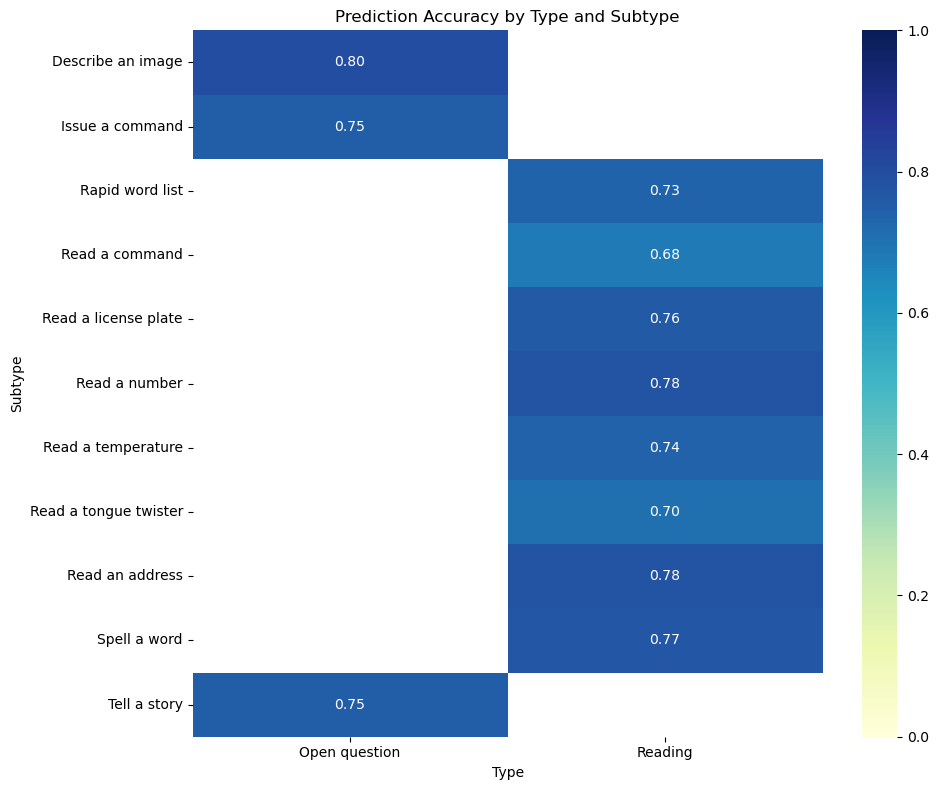

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute aggregated accuracy per Type/Subtype
heatmap_df = (
    merged_dfTrain
    .groupby(['Type','Subtype'])
    .apply(lambda x: (x['DrunkFlag']==x['Prediction']).mean())
    .reset_index(name='Accuracy')
)

pivot_heatmap = heatmap_df.pivot(index='Subtype', columns='Type', values='Accuracy')

plt.figure(figsize=(10,8))
sns.heatmap(pivot_heatmap, annot=True, fmt=".2f", cmap="YlGnBu", vmin=0, vmax=1)
plt.title("Prediction Accuracy by Type and Subtype")
plt.ylabel("Subtype")
plt.xlabel("Type")
plt.tight_layout()
plt.show()
